Classes: ['Dysarthia', 'Laryngitis', 'Laryngozele', 'Vox senilis', 'parkinson', 'spasmodische_dysphonie']
✔ Saved Best Model (Val Acc: 0.4521)
Epoch 1: Train Acc = 0.2576 | Val Acc = 0.4521
✔ Saved Best Model (Val Acc: 0.6027)
Epoch 2: Train Acc = 0.4462 | Val Acc = 0.6027
Epoch 3: Train Acc = 0.5322 | Val Acc = 0.5890
✔ Saved Best Model (Val Acc: 0.6575)
Epoch 4: Train Acc = 0.5892 | Val Acc = 0.6575
✔ Saved Best Model (Val Acc: 0.7123)
Epoch 5: Train Acc = 0.6289 | Val Acc = 0.7123
Epoch 6: Train Acc = 0.6590 | Val Acc = 0.6575
Epoch 7: Train Acc = 0.6879 | Val Acc = 0.6301
Epoch 8: Train Acc = 0.7125 | Val Acc = 0.7123
✔ Saved Best Model (Val Acc: 0.7671)
Epoch 9: Train Acc = 0.7210 | Val Acc = 0.7671
Epoch 10: Train Acc = 0.7381 | Val Acc = 0.7397
Epoch 11: Train Acc = 0.7568 | Val Acc = 0.7534
Epoch 12: Train Acc = 0.7635 | Val Acc = 0.7534
Epoch 13: Train Acc = 0.7757 | Val Acc = 0.7123
Epoch 14: Train Acc = 0.7859 | Val Acc = 0.7534
Epoch 15: Train Acc = 0.7941 | Val Acc = 0.753

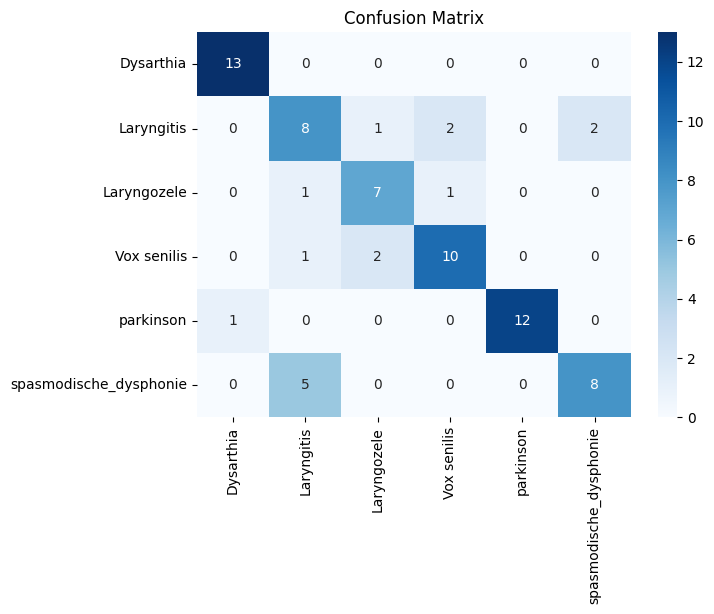

In [4]:
# ===================== STANDALONE CNN TRAINING =====================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
CONFIG = {
    'data_dir': r'A:\Speech Journal\melspectrograms_dataset',    # change to your dataset folder
    'img_size': 224,
    'batch_size': 64,
    'epochs': 15,
    'lr': 1e-3,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'checkpoint_path': 'cnn_best.pth'
}

# ---------------- TRANSFORMS ----------------
train_tf = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor()
])

# ---------------- LOAD DATA ----------------
train_ds = datasets.ImageFolder(os.path.join(CONFIG['data_dir'], 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(CONFIG['data_dir'], 'validation'), transform=test_tf)
test_ds  = datasets.ImageFolder(os.path.join(CONFIG['data_dir'], 'test'), transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

num_classes = len(train_ds.classes)
print("Classes:", train_ds.classes)


# ---------------- SIMPLE CNN MODEL ----------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (CONFIG['img_size']//8) * (CONFIG['img_size']//8), 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# ---------------- TRAINING SETUP ----------------
model = SimpleCNN(num_classes).to(CONFIG['device'])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

best_acc = 0


# ---------------- TRAINING LOOP ----------------
for epoch in range(1, CONFIG['epochs'] + 1):

    # ---- TRAIN ----
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(CONFIG['device']), labels.to(CONFIG['device'])

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_preds.extend(outputs.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)

    # ---- VAL ----
    model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(imgs)
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    # ---- SAVE BEST ----
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CONFIG['checkpoint_path'])
        print(f"✔ Saved Best Model (Val Acc: {val_acc:.4f})")

    print(f"Epoch {epoch}: Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")


# ---------------- TEST ----------------
print("\n===== TEST RESULTS =====")
model.load_state_dict(torch.load(CONFIG['checkpoint_path'], map_location=CONFIG['device']))
model.eval()

test_preds, test_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(CONFIG['device'])
        outputs = model(imgs)
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels.extend(labels.numpy())

print(classification_report(test_labels, test_preds, target_names=test_ds.classes))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_ds.classes, yticklabels=test_ds.classes)
plt.title("Confusion Matrix")
plt.show()


Resnet

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import os

# ---------------- CONFIG ----------------
DATA_DIR = r"A:\Speech Journal\melspectrograms_dataset"
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4
IMG_SIZE = 224
NUM_CLASSES = 6
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- TRANSFORMS ----------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---------------- DATASETS ----------------
train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "validation"),
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=val_test_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Class Mapping:", train_dataset.class_to_idx)

# ---------------- MODEL ----------------
model = models.resnet18(weights="IMAGENET1K_V1")

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

# ---------------- LOSS & OPTIMIZER ----------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ---------------- TRAINING ----------------
def train_epoch(model, loader):
    model.train()
    running_loss, correct = 0.0, 0

    for imgs, labels in tqdm(loader, desc="Training"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return running_loss / len(loader), acc

# ---------------- VALIDATION ----------------
def eval_epoch(model, loader):
    model.eval()
    running_loss, correct = 0.0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Validation"):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return running_loss / len(loader), acc

# ---------------- TRAIN LOOP ----------------
best_val_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet_melspec.pth")
        print("✅ Model Saved")

# ---------------- TEST ----------------
model.load_state_dict(torch.load("best_resnet_melspec.pth"))
test_loss, test_acc = eval_epoch(model, test_loader)

print(f"\n🎯 Test Accuracy: {test_acc:.4f}")


Class Mapping: {'Dysarthia': 0, 'Laryngitis': 1, 'Laryngozele': 2, 'Vox senilis': 3, 'parkinson': 4, 'spasmodische_dysphonie': 5}

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  9.46it/s]


Train Loss: 0.8551 | Train Acc: 0.6625
Val   Loss: 0.6951 | Val   Acc: 0.7123
✅ Model Saved

Epoch 2/30


Validation: 100%|██████████| 5/5 [00:01<00:00,  4.18it/s]


Train Loss: 0.5039 | Train Acc: 0.8053
Val   Loss: 0.6487 | Val   Acc: 0.7671
✅ Model Saved

Epoch 3/30


...

Train Loss: 0.0655 | Train Acc: 0.9769
Val   Loss: 0.5879 | Val   Acc: 0.7808

Epoch 14/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  9.96it/s]


Train Loss: 0.0520 | Train Acc: 0.9843
Val   Loss: 0.8243 | Val   Acc: 0.7945

Epoch 15/30


Training:  15%|█▌        | 39/252 [00:05<00:30,  6.89it/s]


KeyboardInterrupt: 

In [7]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# -------- CONFIG --------
DATA_DIR = r"A:\Speech Journal\melspectrograms_dataset"
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_CLASSES = 6
MODEL_PATH = "best_resnet_melspec.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------- TRANSFORMS --------
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------- DATASET --------
test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = test_dataset.classes
print("Classes:", class_names)

# -------- MODEL --------
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# -------- TEST LOOP --------
all_preds = []
all_labels = []
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"\n🎯 Test Accuracy: {test_acc:.4f}")

# -------- CLASSIFICATION REPORT --------
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(all_labels, all_preds)
print("\n🧩 Confusion Matrix:")
print(cm)


Classes: ['Dysarthia', 'Laryngitis', 'Laryngozele', 'Vox senilis', 'parkinson', 'spasmodische_dysphonie']


Testing: 100%|██████████| 5/5 [00:00<00:00,  6.47it/s]


🎯 Test Accuracy: 0.8378

📊 Classification Report:
                        precision    recall  f1-score   support

             Dysarthia       1.00      1.00      1.00        13
            Laryngitis       0.64      0.69      0.67        13
           Laryngozele       0.73      0.89      0.80         9
           Vox senilis       1.00      0.77      0.87        13
             parkinson       0.93      1.00      0.96        13
spasmodische_dysphonie       0.75      0.69      0.72        13

              accuracy                           0.84        74
             macro avg       0.84      0.84      0.84        74
          weighted avg       0.85      0.84      0.84        74


🧩 Confusion Matrix:
[[13  0  0  0  0  0]
 [ 0  9  2  0  0  2]
 [ 0  0  8  0  1  0]
 [ 0  1  1 10  0  1]
 [ 0  0  0  0 13  0]
 [ 0  4  0  0  0  9]]
